In [1]:
!pip install ~/fwiVis/utility_functions/
! pip install plotnine


Processing /home/jovyan/fwiVis/utility_functions
  Preparing metadata (setup.py) ... done
  Created wheel for fwiVis: filename=fwiVis-0.1-py3-none-any.whl size=17985 sha256=ff105894f5bae756c42254bf9a2b240490d87c825bcff1a536a1a1bcacc632d8
  Stored in directory: /tmp/pip-ephem-wheel-cache-lyjsx4ss/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Attempting uninstall: fwiVis
    Found existing installation: fwiVis 0.1
    Uninstalling fwiVis-0.1:
      Successfully uninstalled fwiVis-0.1


In [2]:
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
#import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain

from datetime import date
from bs4 import BeautifulSoup
import requests
import os
import plotnine
import xarray as xr

#import numpy as np
from matplotlib import pyplot as plt
from plotnine import ggplot, geom_point, geom_jitter, aes, stat_smooth, facet_wrap
import plotnine as plotnine
import seaborn as sns

from scipy import stats
from patsy import ModelDesc
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

import math


In [3]:
import fwiVis.fwiVis as fv

#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_only/April_1_unmerged_fires_with_FWI.csv"
#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Final_dataset_as_of_20240209.csv"
#fire3 = fv.prep_fire_files(path)

#path = os.path.abspath("data/Quebec_v3_full_data_perimeters20241112.csv")
path = os.path.abspath("data/Quebec_v3_full_data_perimetersMAX_fwi_with_ISI_and_BUIful_timeseries_202535.csv")
fire3 = fv.prep_fire_files(path)
fire_first = fire3



In [4]:
fire3 = fire3.sort_values(by = ["fireID", "t"])

fire3 = fire3[~fire3.FWI.isna()]
# df = fire3[fire3.fireID == '2367']
# df


In [5]:
def corrected_farea_diff(df, var = "farea"):
    #sub_df = df[]
    df = df.drop_duplicates()
    df[f"{var}_diff"] = df[var].diff()
    min_t = df.t.min()
    #print()
    #print(df.loc[df.t == min_t, ["fireID", "t", "farea", "farea_diff"]])
    
    if(np.isnan(*df.loc[df.t == min_t, [f"{var}_diff"]].values)):
        df.loc[df.t == min_t, [f"{var}_diff"]] = df.loc[df.t == min_t, [f"{var}"]].values
    else:
        print("Error! First value not NaN")
        df = None
    return(df)

In [6]:
def just_the_igs(df,): ## Reminder that this will only acocunt for the earliest ignition from a multi-fire complex. 

    df["is_ig"] = False
    df.loc[df.t == df.t.min(), ['is_ig']] = True
    
    return(df)

def extinction(df, days_past = 1):
    df.loc[:, ['is_ext']] = False
    df.loc[:, ["t"]] = df.t.astype("datetime64[ns]")
    final_t = df[df.n_newpixels > 0].t.astype("datetime64[ns]").max()
    post_fire = final_t + timedelta(days = days_past)

    if (pd.isnull(np.datetime64(str(final_t)))):
        df.loc[(df.t == df.t.min()), ['is_ext']] = True
    else:
        df.loc[(df.t  > final_t)  & (df.t  <= post_fire), ['is_ext']] = True
    #print(final_t)
    #print(df.fireID.unique())
    #print(len(df[df["is_ext"] == True]))
    return(df)


fire3 = fire3[~fire3.FWI.isna()]





In [7]:
def chop_fires_at_end(df):
    final_t = df[df.n_newpixels > 0].t.max()
    df = df[df.t <= final_t]
    return(df)

#post_fr = fire3.groupby("fireID").apply(extinction).reset_index(drop = True)
fire3 = fire3.groupby("fireID").apply(chop_fires_at_end).reset_index(drop = True)


fire3 = fire3.sort_values(by = ["fireID", "t"])
fire3 = fire3[~fire3.FWI.isna()]

/tmp/ipykernel_1188/455317430.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [8]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [9]:
### make a plot of the distribution of forwar-facing relative fire area growth
fire3 = fire3.drop_duplicates()
fire3["farea_diff_stand"] = fire3.groupby("fireID").farea.diff()

fire3["corrected_flinelen"] = fire3.flinelen + 0.001

## Fireline 
fire3["frac_change"] = fire3.groupby("fireID").farea.pct_change()
fire3["flinelen_frac_change"] = fire3.groupby("fireID").corrected_flinelen.pct_change()

fire3["fperim_shifted"] = fire3.groupby("fireID").fperim.shift(periods = 1)
fire3["flinelen_diff"] = fire3.groupby("fireID").flinelen.diff()
fire3["fperim_diff"] = fire3.groupby("fireID").fperim.diff()
fire3["farea_shifted_back"] = fire3.groupby("fireID").farea.shift(periods = 1)


fire3["farea_shifted"] = fire3.groupby("fireID").farea.shift(periods = 1)
fire3["meanFRP_shifted"] = fire3.groupby("fireID").meanFRP.shift(periods = 1)
fire3["flinelen_shifted"] = fire3.groupby("fireID").flinelen.shift(periods = 1)
fire3["n_newpixels_shifted"] = fire3.groupby("fireID").n_newpixels.shift(periods = 1)
fire3["GEOS5_IMERGEARLY_shifted"] = fire3.groupby("fireID")['GEOS-5.IMERGEARLY'].shift(periods = 1)
fire3["FWI_shifted"] = fire3.groupby("fireID")['FWI'].shift(periods = 1)
fire3["FWI_lead_1_shifted"] = fire3.groupby("fireID")['FWI_lead_1'].shift(periods = 1)
fire3["FWI_forecast_average"] = (fire3.FWI + fire3.FWI_lead_1)/2
fire3["FWI_forecast_average_shifted"] = (fire3.FWI_shifted + fire3.FWI_lead_1_shifted)/2
fire3["ISI_shifted"] = fire3.groupby("fireID")['ISI'].shift(periods = 1)
fire3["ISI_lead_1_shifted"] = fire3.groupby("fireID")['ISI_lead_1'].shift(periods = 1)
fire3["ISI_forecast_average"] = (fire3.ISI + fire3.ISI_lead_1)/2
fire3["ISI_forecast_average_shifted"] = (fire3.ISI_shifted + fire3.ISI_lead_1_shifted)/2
fire3["BUI_shifted"] = fire3.groupby("fireID")['BUI'].shift(periods = 1)
fire3["BUI_lead_1_shifted"] = fire3.groupby("fireID")['BUI_lead_1'].shift(periods = 1)
fire3["BUI_forecast_average"] = (fire3.BUI + fire3.BUI_lead_1)/2
fire3["BUI_forecast_average_shifted"] = (fire3.BUI_shifted + fire3.BUI_lead_1_shifted)/2




fire3["corrected_shifted_flinelen"] = fire3.flinelen_shifted + 0.001
fire3["flinelen_shifted_frac_change"] = fire3.groupby("fireID").corrected_shifted_flinelen.pct_change()

fire3["farea_shifted_exp"] = fire3["farea_shifted"] ** (1/10)
fire3["meanFRP_shifted_exp"] = fire3["meanFRP_shifted"]** (1/10)
fire3["flinelen_shifted_exp"] = fire3["flinelen_shifted"]** (1/10)
fire3["n_newpixels_shifted_exp"] = fire3["n_newpixels_shifted"]** (1/10)


fire3["spread_bool"] = fire3.frac_change > 0
fire3["spread_bool"] = fire3["spread_bool"].astype("int")


fire3["spread_bool_50"] = fire3.frac_change > 0.5
fire3["spread_bool_50"] = fire3["spread_bool_50"].astype("int")


fire3["spread_bool_100"] = fire3.frac_change > 1
fire3["spread_bool_100"] = fire3["spread_bool_100"].astype("int")

/tmp/ipykernel_1188/689482210.py:8: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
/tmp/ipykernel_1188/689482210.py:9: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
/tmp/ipykernel_1188/689482210.py:39: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.


In [10]:
### Incorperate robert's radius prediction. Note: this is basing thins on FWI instead of ISI, and is temporarily ignooring the effect of the BUI. 
from math import e
from math import pi


### Implement BUI

def get_ros(df, isi_var, bui_var, a = 110, b = 0.0282, c = 1.5, spread_hours = 4, BUIo = 64, q = 0.70, lab = ""):
    df.loc[:, f"initial_rate_of_spread{lab}"] = a* (( 1 - (e**(-b * df[isi_var])))** c)
    df.loc[:, f"buildup_effect{lab}"] = e**(50 * (np.log(q)) * ((1/df[bui_var]) - (1/BUIo)))  #BuildupEffect = exp(50*log(q)*(1/BUIforROS - 1/BUIo))
    df.loc[:, f"rate_of_spread_eq{lab}"] = df[f"buildup_effect{lab}"] * df[f"initial_rate_of_spread{lab}"]
    df.loc[:, f"rate_of_spread{lab}"] = (df.loc[:, f"rate_of_spread_eq{lab}"]*(spread_hours*60)) / 1000
    return(df)
# def get_radius(df):
#     df.loc[:, "radius"] = (df.farea/pi)^(1/2)
#     return(df)

fire3 = get_ros(fire3, isi_var = "ISI", bui_var = "BUI")
fire3 = get_ros(fire3, isi_var = "ISI_forecast_average_shifted", bui_var = "BUI_forecast_average_shifted", lab = "_forecast_average_shifted") #FWI_forecast_average_shifted
fire3.loc[:, "radius"] = (fire3.farea_diff_stand/pi)**(1/2)


In [11]:
fire3 = fire3.sort_values(by = ["fireID", "t"])
fire3 = fire3[~fire3.BUI.isna()]
fire3 = fire3.groupby("fireID").apply(corrected_farea_diff).reset_index(drop = True) ## No supression signal for now. 

/tmp/ipykernel_1188/999561434.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [12]:
def relative_growth(df):
    df["relative_growth"] =  (df.farea_diff + df.farea_shifted_back) / df.farea_shifted_back
    return(df)



In [13]:
fire3 = fire3.groupby("fireID").apply(relative_growth).reset_index(drop = True)

/tmp/ipykernel_1188/4158884599.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


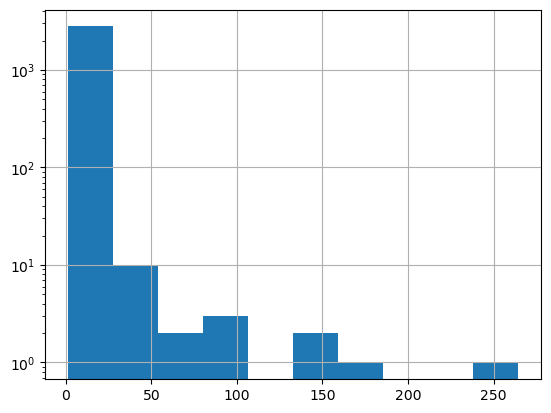

In [14]:
fire3.relative_growth.hist()
plt.yscale("log")

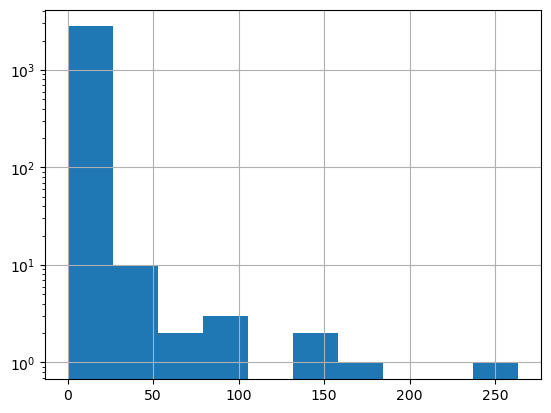

In [15]:
fire3.frac_change.hist()
plt.yscale("log")

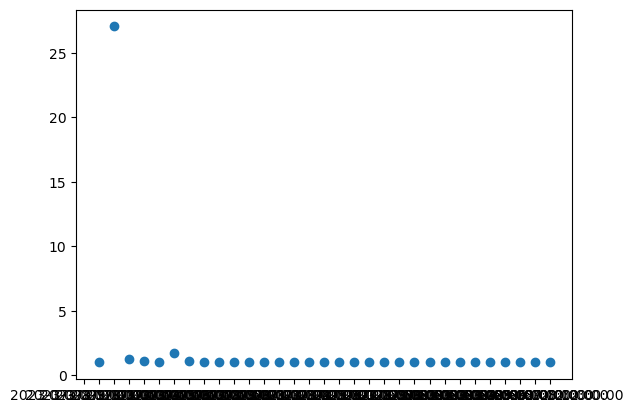

<Figure size 640x480 with 0 Axes>

In [16]:
plt.scatter(fire3[fire3.fireID == '2729'].t, fire3[fire3.fireID == '2729'].relative_growth)
plt.show()
plt.clf()

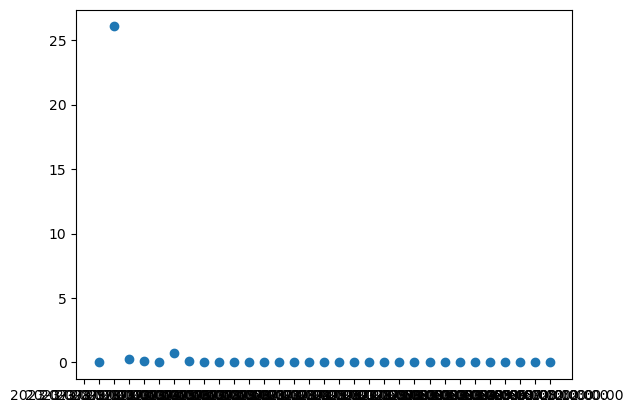

<Figure size 640x480 with 0 Axes>

In [17]:



plt.scatter(fire3[fire3.fireID == '2729'].t, fire3[fire3.fireID == '2729'].frac_change.round(3))
plt.show()
plt.clf()

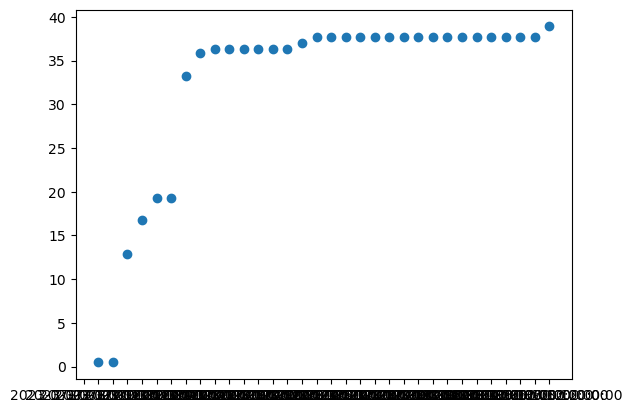

In [18]:
plt.scatter(fire3[fire3.fireID == '2729'].t, fire3[fire3.fireID == '2729'].farea)
#plt.scatter(fire3[fire3.fireID == '2729'].t, fire3[fire3.fireID == '2729'].farea_shifted_back, color = "red")

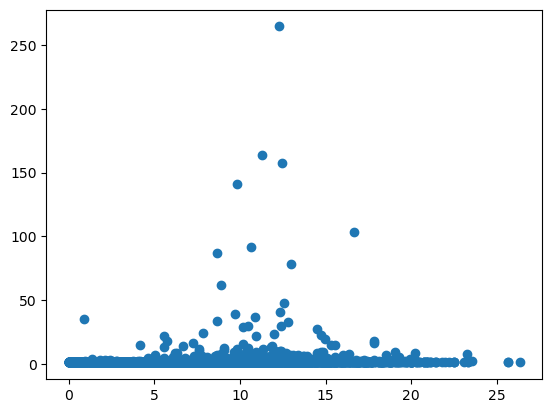

In [19]:
plt.scatter(fire3['GEOS-5.IMERGEARLY'], fire3.relative_growth)

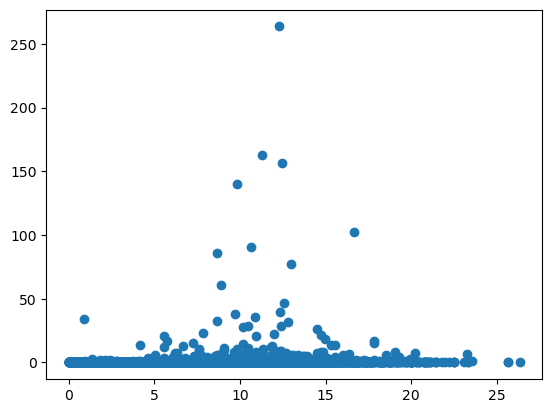

In [20]:
plt.scatter(fire3['GEOS-5.IMERGEARLY'], fire3.frac_change)

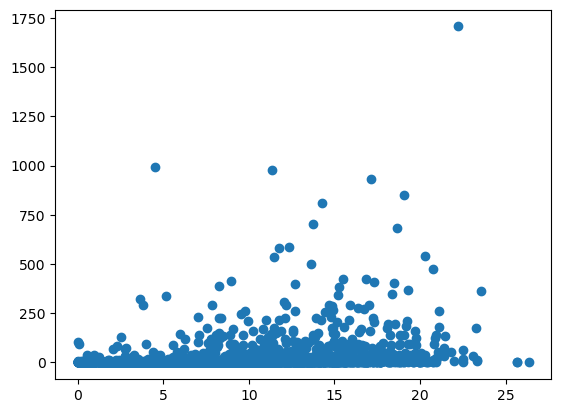

0        False
1        False
2        False
3        False
4        False
         ...  
11175    False
11176    False
11177    False
11178    False
11179    False
Length: 11180, dtype: bool


In [21]:
fire3 = fire3.sort_values(by = ["fireID", "t"])


fire3.loc[:, "farea_diff_stand"] = fire3.groupby("fireID").farea.diff()

plt.scatter(fire3['GEOS-5.IMERGEARLY'], fire3.farea_diff_stand)
plt.show()
plt.close()

print(fire3.farea_diff_stand == fire3.farea_diff)

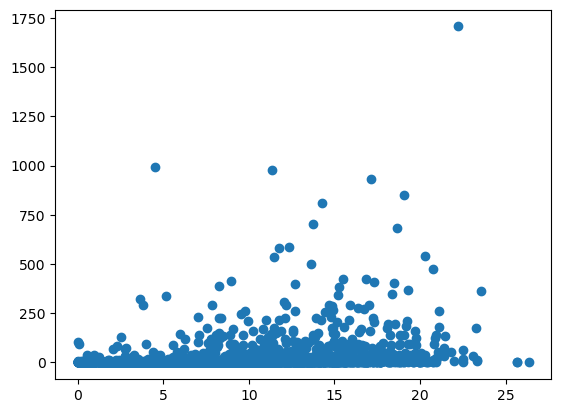

0        False
1        False
2        False
3        False
4        False
         ...  
11175    False
11176    False
11177    False
11178    False
11179    False
Name: farea_diff_stand, Length: 11180, dtype: bool


In [22]:
fire3 = fire3.sort_values(by = ["fireID", "t"])


fire3.loc[:, "r"] = fire3.groupby("fireID").farea.diff()

plt.scatter(fire3['GEOS-5.IMERGEARLY'], fire3.farea_diff_stand)
plt.show()
plt.close()

print(fire3.farea_diff_stand == fire3.farea_diff_stand)

In [23]:
def get_diff_devided_by_first_sight(df):
    first_sight = df.farea.min()
    df.loc[:, "farea_diff_first_sight"] = (df.farea.diff() / first_sight)
    return(df)

def get_diff_devided_by_previous_t(df):
    #first_sight = df.farea.min()
    df.loc[:, "farea_diff_prev_t"] = (df.farea.diff() / df.farea.shift(1))
    return(df)

fire3  = fire3.groupby("fireID").apply(get_diff_devided_by_first_sight).reset_index(drop = True)
fire3  = fire3.groupby("fireID").apply(get_diff_devided_by_previous_t).reset_index(drop = True)

fire3['GEOS5_IMERGEARLY'] = fire3['GEOS-5.IMERGEARLY']

/tmp/ipykernel_1188/1139180803.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_1188/1139180803.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


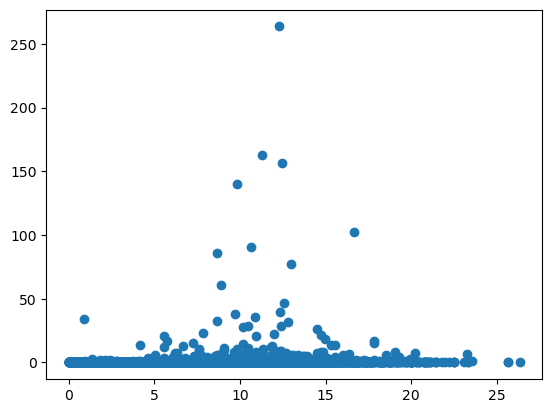

In [24]:
plt.scatter(fire3['GEOS-5.IMERGEARLY'], fire3.farea_diff_prev_t)
plt.show()
plt.close()

In [25]:
### Step 1 -- calculate a "general" rate of spread based on logarithmic growth



### Step 2 reample from a subset of that dataset to get an estimate of R



## Step three, look at the predicted vs observed for what was predicted based on equations vs what we saw. 


### Step for -- maybe estimate a Y (R) ~ X ()

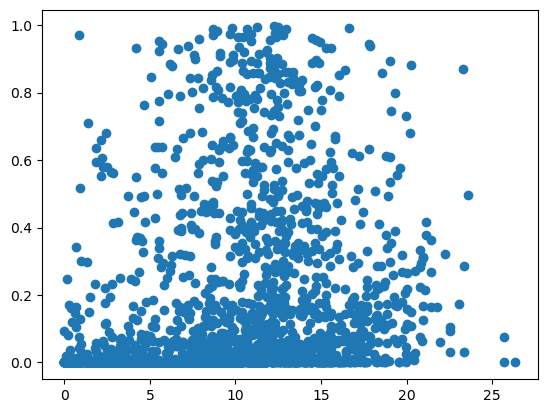

In [26]:
plt.scatter(fire3['GEOS-5.IMERGEARLY'], fire3.farea_diff/fire3.farea)
plt.show()
plt.close()

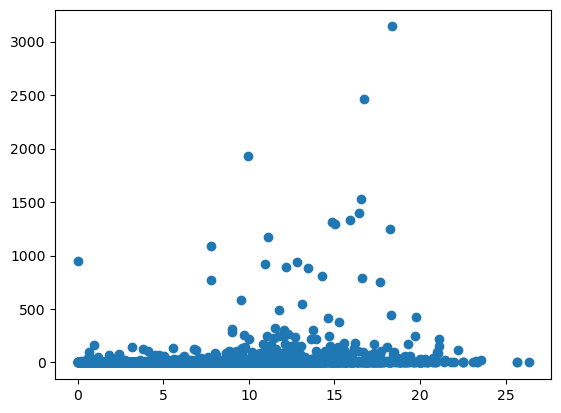

In [27]:
plt.scatter(fire3['GEOS-5.IMERGEARLY'], fire3.farea_diff_first_sight)
plt.show()
plt.close()

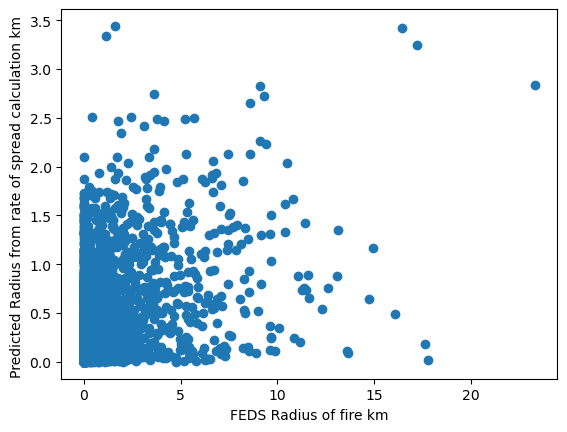

In [28]:

def chop_fires_after_(df):
    final_t = df[df.n_newpixels > 0].t.max()
    df = df[df.t <= final_t]
    return(df)


plt.scatter(y = fire3['rate_of_spread_forecast_average_shifted'], x = fire3['radius'])
plt.ylabel("Predicted Radius from rate of spread calculation km ")
plt.xlabel("FEDS Radius of fire km")
plt.show()
plt.close()

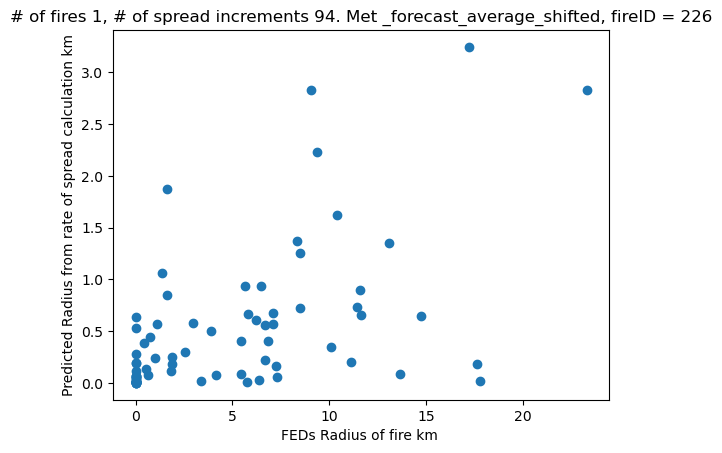

In [29]:
met = '_forecast_average_shifted'
fireID = "226"


largest_fires_40 = fire3.groupby('fireID').farea.max()
largest_fires_40 = largest_fires_40.sort_values(ascending = False)
largest_fires_40 = largest_fires_40[0:1]
row_mask = fire3.fireID.isin(largest_fires_40.index)

row_mask = fire3.fireID == fireID

plt.scatter(y = fire3.loc[row_mask, f'rate_of_spread{met}'], x = fire3.loc[row_mask,'radius'])
plt.ylabel("Predicted Radius from rate of spread calculation km")
plt.xlabel("FEDs Radius of fire km ")
plt.title(f"# of fires {len(fire3.loc[row_mask, "fireID"].unique())}, # of spread increments {len(fire3.loc[row_mask, "fireID"])}. Met {met}, fireID = {fireID}")
plt.show()
plt.close()

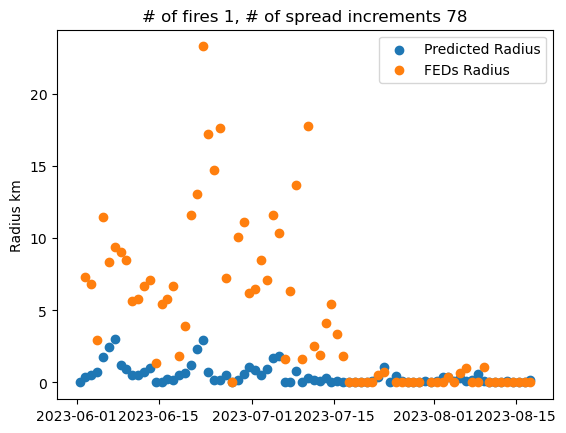

In [30]:
row_mask = fire3.fireID.isin(largest_fires_40.index) & ~fire3.geometry.isnull()

plt.scatter(y = fire3.loc[row_mask, 'rate_of_spread'], x = fire3.loc[row_mask].t.astype("datetime64[ns]"), label = "Predicted Radius")
plt.scatter(y = fire3.loc[row_mask, 'radius'], x = fire3.loc[row_mask].t.astype("datetime64[ns]"), label = "FEDs Radius")

plt.ylabel("Radius km")
plt.legend()
#plt.xlabel(" ")
plt.title(f"# of fires {len(fire3.loc[row_mask, "fireID"].unique())}, # of spread increments {len(fire3.loc[row_mask, "fireID"])}")
plt.show()
plt.close()

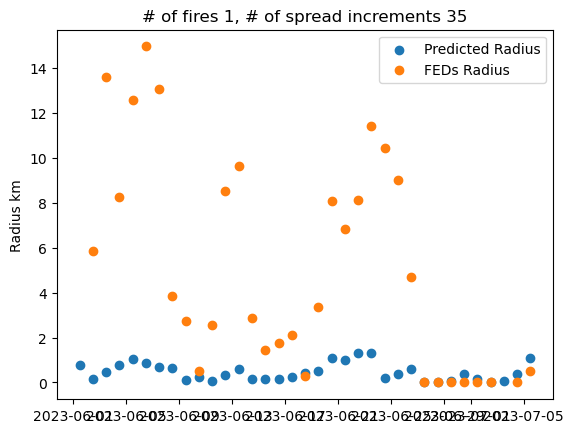

In [31]:
largest_fires_40 = fire3.groupby('fireID').farea.max()
largest_fires_40 = largest_fires_40.sort_values(ascending = False)
largest_fires_40 = largest_fires_40[1:2]
row_mask = fire3.fireID.isin(largest_fires_40.index)


row_mask = fire3.fireID.isin(largest_fires_40.index)  & ~fire3.geometry.isnull()

plt.scatter(y = fire3.loc[row_mask, 'rate_of_spread'], x = fire3.loc[row_mask].t.astype("datetime64[ns]"), label = "Predicted Radius")
plt.scatter(y = fire3.loc[row_mask, 'radius'], x = fire3.loc[row_mask].t.astype("datetime64[ns]"), label = "FEDs Radius")
plt.legend()
plt.ylabel("Radius km")
#plt.xlabel(" ")
plt.title(f"# of fires {len(fire3.loc[row_mask, "fireID"].unique())}, # of spread increments {len(fire3.loc[row_mask, "fireID"])}")
plt.show()
plt.close()

In [32]:
### Models of farea



import statsmodels.api as sm
import statsmodels.formula.api as smf

In [33]:
def log_farea_diff(df):
    df["log_farea"] = np.log(df.farea)
    df["log_farea_diff"] = df.log_farea.diff()
    return(df)

fire3  = fire3.groupby("fireID").apply(log_farea_diff).reset_index(drop = True)

/tmp/ipykernel_1188/564016344.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


<Axes: >

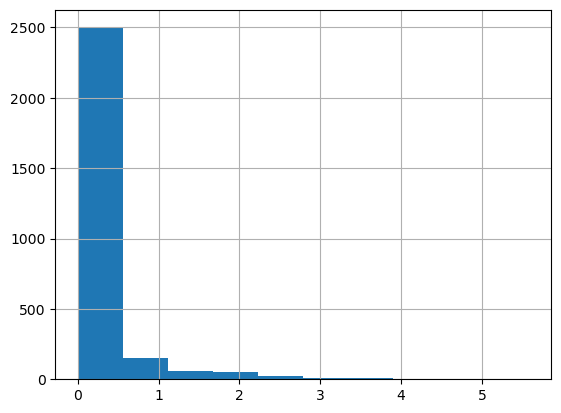

In [34]:
fire3.log_farea_diff.hist()

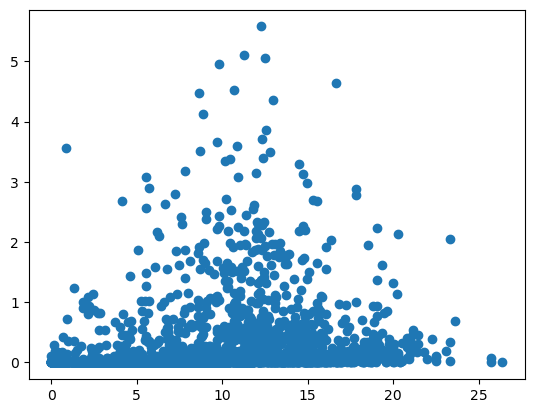

In [35]:
plt.scatter(fire3['GEOS-5.IMERGEARLY'], fire3.log_farea_diff)




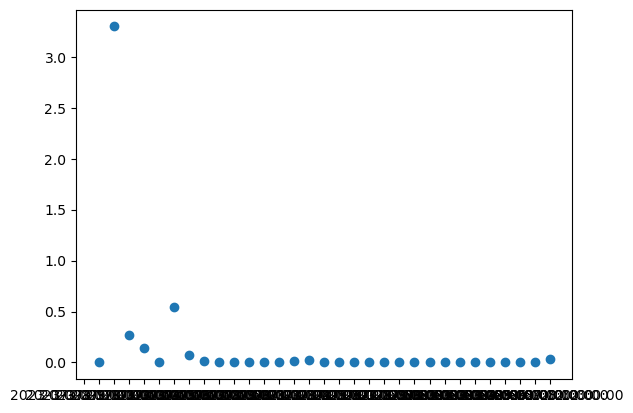

In [36]:

plt.scatter(fire3[fire3.fireID == '2729'].t, fire3[fire3.fireID == '2729'].log_farea_diff)

##plt.scatter(fire3['GEOS-5.IMERGEARLY'], fire3.farea_diff)

## Model notes


farea_diff = farea * R ## NUll model fit on half, just to predict other half with  #N(t) = N₀ * e^(rt), notation once R is known. 

^Could also benchmarck this and use as seperate null model

farea_diff ~ farea * R 

farea_diff = farea * R-modified by weather @ t


farea_diff/farea = R


ln(N_t) = r(_t)

 R_logged_farea_diff ~ fline_len_prev

R_logged_farea_diff ~ fline_len_prev + FWI

R_logoed_farea_diff ~ FRP + FWI
 R_logoed_farea_diff ~ FRP 

R_logoed_farea_diff ~ BUI

# Y's and X's

Y's :
- farea_diff
- R_logged_farea_diff
- frac_change
- relative_growth

X's
- farea_prev
- flinelen_prev
- FWI
- ISI
- BUI
- ISI + BUI
- FRP
- 

# Make Sampleing Scheme

I want to generate "rate parameters" that I can then test the skill of against out-of-sample fires. I want to make two-halves, each with a similar representation of large fires and small fires. 

Seems like "greedy matching" where you sort by and then create one and then the other, is pretty good. 


In [37]:
max_area = fire3.groupby("fireID").farea.max()
max_area = pd.DataFrame({"fireID": max_area.index, 
                        "farea_max" : max_area.values})


max_area = max_area.sort_values(by = "farea_max")
fit_ids = max_area.iloc[::2].fireID
test_ids = max_area.iloc[1::2].fireID



fire = fire3[fire3.fireID.isin(fit_ids)]
fire_test = fire3[fire3.fireID.isin(test_ids)]


In [38]:
fire_vals = ["farea_shifted", "flinelen_shifted", "meanFRP_shifted", 'n_newpixels_shifted', "farea_shifted_exp", "flinelen_shifted_exp", "meanFRP_shifted_exp", 'n_newpixels_shifted_exp']
weather_vals = ['GEOS5_IMERGEARLY']

x_combos = [(f, w) for f in fire_vals for w in weather_vals]

x_vals = [*fire_vals, *weather_vals, *x_combos,]
y_vals = ["frac_change", 'relative_growth', 'log_farea_diff', 'farea_diff_stand']



def make_multivariate_model(fire_delta, fire_test, x, y):
    #fire_delta = fire_delta[[x, y]].dropna()
    fire_delta = fire_delta[[*x, y]].drop_duplicates()
    fire_delta = fire_delta[[*x , y]].dropna()

    fire_test = fire_test[[*x, y]].drop_duplicates()
    fire_test = fire_test[[*x, y]].dropna()

    # if len(x) == 2:
    #     formula = f"{y} ~ {x[0]} * {x[1]}"
    # if len(x) == 3:
    #     formula = f"{y} ~ {x[0]} * {x[1]} * {x[2]}"
    # else: 
    #     formula = f"{y} ~ {x}"

    formula = f"{y} ~ {x[0]} * {x[1]}"
    #formula = f"{y} ~ {x}"
    #links = "Identity"
    #links = "CLogLog"
    #links = "LogLog"
    #links = "Log"
    #links = "InverseSquared"
    #links = "InversePower"
    #links = "Inverse"
    links = "Power"
    #families = "Gamma"
    #families = "Gamma"
    #families = "Gaussian"
    families = "Tweedie"
    #variance_name = "mu_cubed"
    #varience_g = getattr(sm.genmod.families.varfuncs, variance_name)
    
    link_g = getattr(sm.genmod.families.links, links)
    method = getattr(sm.families, families)
    
    model = smf.glm(formula, data=fire_delta, family= method(link = link_g(1/10),  check_link=True)).fit() # alpha = 10 # family=method(link = link_g(),  check_link=True)

    for i, xs in enumerate(x):
        sns.jointplot(data=fire_delta, x= xs, y=y, marker="+",  dropna = True, marginal_kws = {"bins": 20}) #  marginal_kws = {"log_scale": True} 
        #t.ax_marg_y.set_yscale("log")
        max_of_max = round(max(fire_delta[xs].max(), fire_delta[y].max()))
        min_of_min = round(min(fire_delta[xs].min(), fire_delta[y].min()))
        fire_delta['fitted'] = model.fittedvalues
        fire_delta['residuals'] = model.resid_response
        fire_delta = fire_delta.sort_values(by = xs)
        predictions = model.get_prediction(fire_delta, transform = True) #df, transform = False
        fire_delta['predicted'] = predictions.predicted_mean
        fire_delta['conf_int_low'], fire_delta['conf_int_high'] = predictions.conf_int().T
        plt.fill_between(fire_delta[xs], fire_delta['conf_int_low'], fire_delta['conf_int_high'], alpha=0.2, color = "yellow")
        sns.lineplot(x=xs, y='predicted', data=fire_delta, legend = False)
        plt.show()
        
    
    predictions = model.get_prediction(fire_test, transform = True) #df, transform = False
    #return(predictions)
    fire_test['predicted'] = predictions.predicted_mean
    fire_test['conf_int_low'], fire_test['conf_int_high'] = predictions.conf_int().T

    err_var = fire_test.loc[:, ['conf_int_high', 'conf_int_low',]].T
    y_name = y
    sns.jointplot(data=fire_test, x= y , y='predicted') 
    max_of_max = math.ceil(max(fire_test[f"{y_name}"].max(), fire_test['predicted'].max()))
    min_of_min = math.ceil(min(fire_test[f"{y_name}"].min(), fire_test['predicted'].min()))
    #plt.errorbar(x = fire_test[y_name], y = fire_test["predicted"], yerr = err_var, alpha=0.2, color = "yellow", fmt='none')
    plt.plot(range(min_of_min, max_of_max), range(min_of_min, max_of_max), color = "black")
    plt.xlabel(f"Observed Out of Sample {y_name}")
    plt.ylabel(f"Predicted {y_name}")
    plt.show()
    
    # ## Stats
    # r_sq = 1 - (np.sum((fire_delta.diff_FWI - fire_delta[f"diff_FWI_lead_{i}"])**(2)) / np.sum((fire_delta.diff_FWI - fire_delta.diff_FWI.mean())**(2)))
    # bias = np.sum(fire_delta[f"diff_FWI_lead_{i}"] - fire_delta.diff_FWI )/len(fire_delta.diff_FWI)
    # #plt.title(f"Comparison at lag {i}")
    # print(f"Summary Statistics for lag {i}")
    # print("R^2 from 1:1 (Variance explained): " + str(r_sq) )
    # print("Overall Bias/ mean predictor error: " + str(bias) )
    
    
    
    


    # sns.lineplot(x=x, y='predicted', data=fire_delta, legend = False)
    #plt.plot(range(min_of_min, max_of_max), range(min_of_min, max_of_max), color = "black")
    #plt.xlabel(x)
    #plt.ylabel(y)

    # Save a pickled version of the model
    #model.save(f'{os.path.abspath("pickled_models")}/{y}_vs_{"_".join(x)}.pkl')
    
    ## Stats

    return(model)

def make_univariate_model(fire_delta, fire_test, x, y):
    #fire_delta = fire_delta[[x, y]].dropna()
    fire_delta = fire_delta[[x, y]].drop_duplicates()
    fire_delta = fire_delta[[x , y]].dropna()

    fire_test = fire_test[[x, y]].drop_duplicates()
    fire_test = fire_test[[x, y]].dropna()

    # if len(x) == 2:
    #     formula = f"{y} ~ {x[0]} * {x[1]}"
    # if len(x) == 3:
    #     formula = f"{y} ~ {x[0]} * {x[1]} * {x[2]}"
    # else: 
    #     formula = f"{y} ~ {x}"

    #formula = f"{y} ~ {x[0]} * {x[1]}"
    formula = f"{y} ~ {x}"
    #links = "Identity"
    #links = "CLogLog"
    #links = "LogLog"
    #links = "Log"
    #links = "InverseSquared"
    #links = "InversePower"
    #links = "Inverse"
    links = "Power"
    #families = "Gamma"
    #families = "Gamma"
    #families = "Gaussian"
    #families = "NegativeBinomial"
    families = "Tweedie"
    #variance_name = "mu_cubed"
    #varience_g = getattr(sm.genmod.families.varfuncs, variance_name)
    
    link_g = getattr(sm.genmod.families.links, links)
    method = getattr(sm.families, families)
    pre_model = smf.glm(formula, data=fire_delta, family= method(link = link_g(1/10),  check_link=True)) #1/10
    model = pre_model.fit() # alpha = 10 # family=method(link = link_g(),  check_link=True)
    #return([pre_model, model])

    sns.jointplot(data=fire_delta, x= x, y=y, marker="+",  dropna = True, marginal_kws = {"bins": 20}) #  marginal_kws = {"log_scale": True} 
    #t.ax_marg_y.set_yscale("log")
    max_of_max = round(max(fire_delta[x].max(), fire_delta[y].max()))
    min_of_min = round(min(fire_delta[x].min(), fire_delta[y].min()))
    fire_delta['fitted'] = model.fittedvalues
    fire_delta['residuals'] = model.resid_response
    fire_delta = fire_delta.sort_values(by = x)
    predictions = model.get_prediction(fire_delta, transform = True) #df, transform = False
    fire_delta['predicted'] = predictions.predicted_mean
    fire_delta['conf_int_low'], fire_delta['conf_int_high'] = predictions.conf_int().T
    plt.fill_between(fire_delta[x], fire_delta['conf_int_low'], fire_delta['conf_int_high'], alpha=0.2, color = "yellow")
    sns.lineplot(x=x, y='predicted', data=fire_delta, legend = False)
    plt.show()
        
    
    predictions = model.get_prediction(fire_test, transform = True) #df, transform = False
    #return(predictions)
    fire_test['predicted'] = predictions.predicted_mean
    fire_test['conf_int_low'], fire_test['conf_int_high'] = predictions.conf_int().T

    err_var = fire_test.loc[:, ['conf_int_high', 'conf_int_low',]].T
    y_name = y
    sns.jointplot(data=fire_test, x= y , y='predicted') 
    max_of_max = math.ceil(max(fire_test[f"{y_name}"].max(), fire_test['predicted'].max()))
    min_of_min = math.ceil(min(fire_test[f"{y_name}"].min(), fire_test['predicted'].min()))
    plt.errorbar(x = fire_test[y_name], y = fire_test["predicted"], yerr = err_var, alpha=0.2, color = "yellow", fmt='none')
    plt.plot(range(min_of_min, max_of_max), range(min_of_min, max_of_max), color = "black")
    plt.xlabel(f"Observed Out of Sample {y_name}")
    plt.ylabel(f"Predicted {y_name}")
    plt.show()
    
    # ## Stats
    # r_sq = 1 - (np.sum((fire_delta.diff_FWI - fire_delta[f"diff_FWI_lead_{i}"])**(2)) / np.sum((fire_delta.diff_FWI - fire_delta.diff_FWI.mean())**(2)))
    # bias = np.sum(fire_delta[f"diff_FWI_lead_{i}"] - fire_delta.diff_FWI )/len(fire_delta.diff_FWI)
    # #plt.title(f"Comparison at lag {i}")
    # print(f"Summary Statistics for lag {i}")
    # print("R^2 from 1:1 (Variance explained): " + str(r_sq) )
    # print("Overall Bias/ mean predictor error: " + str(bias) )
    
    
    
    


    # sns.lineplot(x=x, y='predicted', data=fire_delta, legend = False)
    #plt.plot(range(min_of_min, max_of_max), range(min_of_min, max_of_max), color = "black")
    #plt.xlabel(x)
    #plt.ylabel(y)

    # Save a pickled version of the model
    #model.save(f'{os.path.abspath("pickled_models")}/{y}_vs_{"_".join(x)}.pkl')
    
    ## Stats

    return(model)

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1650: RuntimeWarning: divide by zero encountered in log
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1650: RuntimeWarning: invalid value encountered in multiply


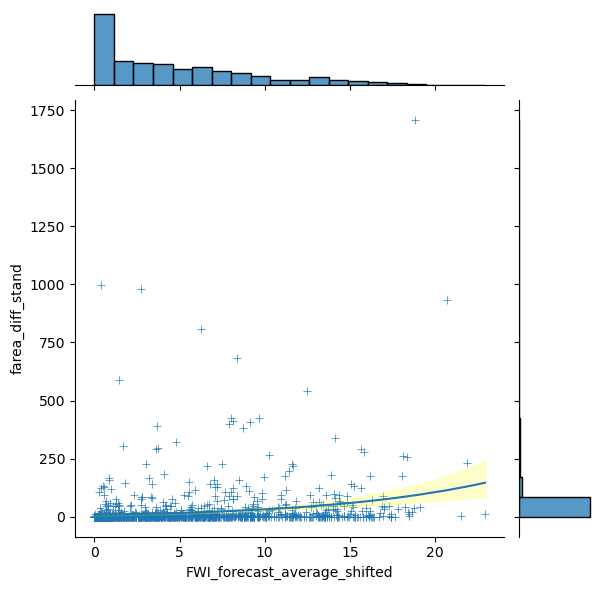

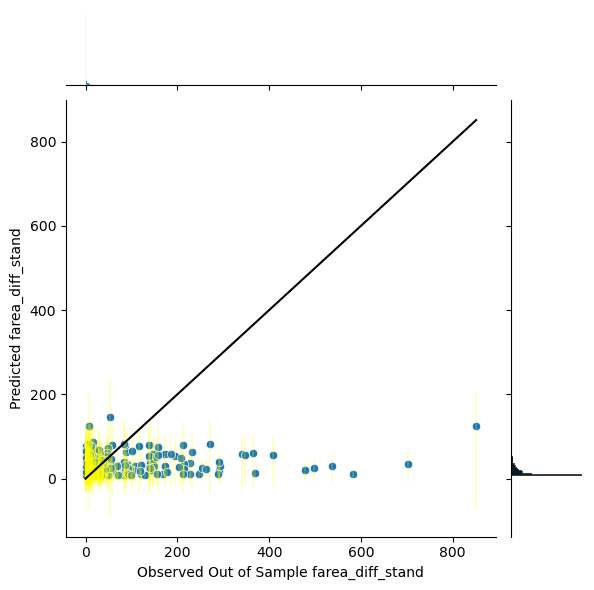

In [39]:
y = 'farea_diff_stand'

fire.loc[:, y] = fire[y].round(4)
fire.loc[fire[y] < 0 , y] = 0

#fire_tmp = fire[fire[y] > 0]

fire_test.loc[:, y] = fire_test[y].round(4)
fire_test.loc[fire_test[y] < 0 , y] = 0
#fire_test_tmp = fire_test[fire_test[y] > 0]



tmp = make_univariate_model(fire, fire_test, x = 'FWI_forecast_average_shifted', y = y)
#pre_model = tmp[0]
#fit = tmp[1]

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1650: RuntimeWarning: divide by zero encountered in log
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1650: RuntimeWarning: invalid value encountered in multiply


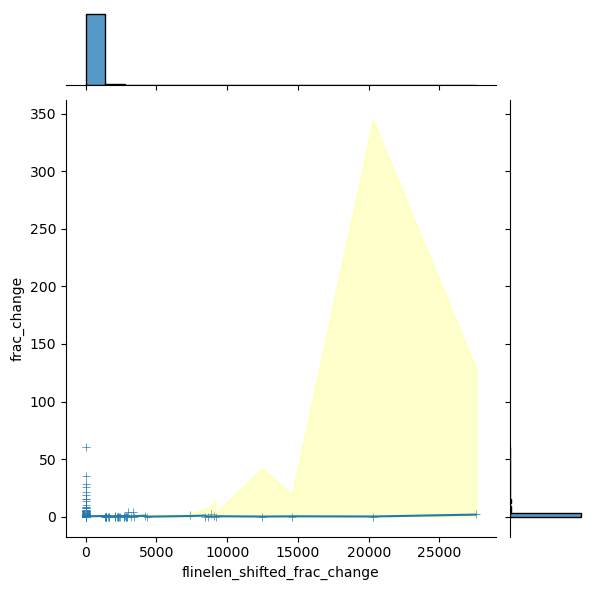

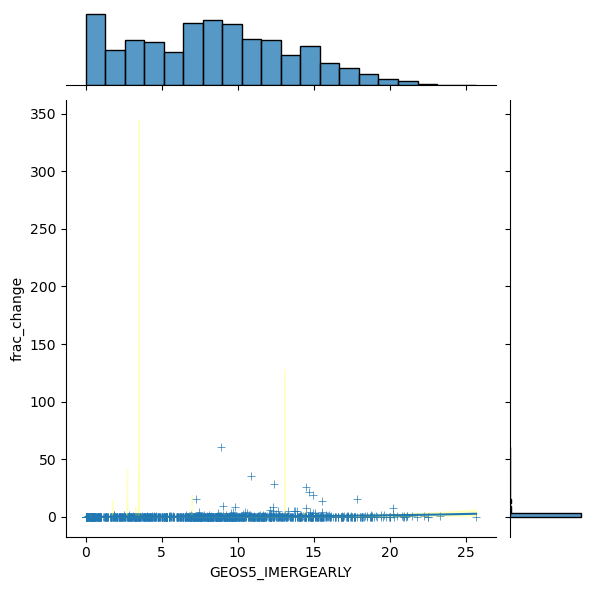

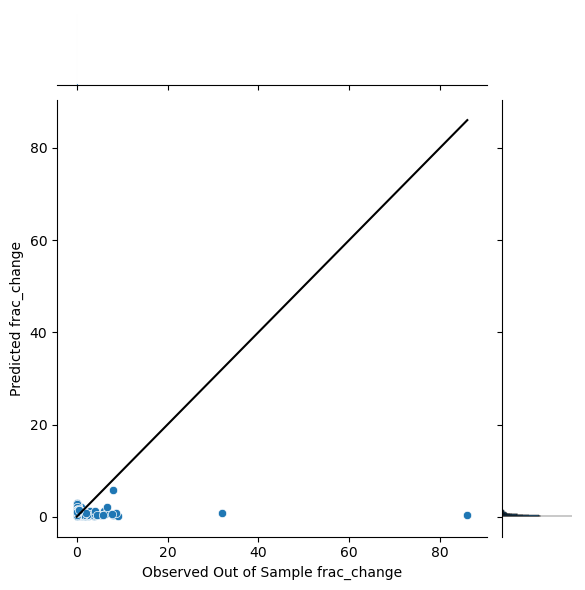

In [40]:
y = 'frac_change'

fire.loc[:, y] = fire[y].round(3)
fire.loc[fire[y] < 0 , y] = 0

#fire_tmp = fire[fire[y] > 0]

fire_test.loc[:, y] = fire_test[y].round(3)
fire_test.loc[fire_test[y] < 0 , y] = 0
#fire_test_tmp = fire_test[fire_test[y] > 0]



tmp = make_multivariate_model(fire, fire_test, x = ('flinelen_shifted_frac_change', 'GEOS5_IMERGEARLY'), y = y)
#pre_model = tmp[0]
#fit = tmp[1]

In [41]:
# y = 'frac_change'

# fire.loc[:, y] = fire[y].round(3)
# fire_test.loc[:, y] = fire_test[y].round(3)
# make_multivariate_model(fire, fire_test, x = x_combos[1], y = y)

# combinations = [(x, y) for x in x_vals for y in y_vals]


# today = datetime.today()

# for i, c in enumerate(combinations):
#     x = c[0]
#     y = c[1]
#     tmp = make_multivariate_model(fire, x,  y)
    

In [42]:
### Test understanding with a custom example

import scipy.stats as spst
from scipy.stats import norm
from scipy.stats import nbinom

In [43]:
# test_y = nbinom.rvs(loc=3,n = 4, p =1/2, size=100, random_state=10)

# test_x = (test_y/2) + norm.rvs(loc=1, scale=1, size=100, random_state=12)


# test_stats = pd.DataFrame({"x": test_x, "y": test_y})

# test_oos = test_stats[0:49]
# test_stats = test_stats[50:99]

In [44]:
# make_multivariate_model(test_stats, test_oos, "x", 'y')


In [45]:


#plt.hist(fire3[fire3.farea_diff > 0].farea_diff_stand**(1/10))

In [46]:
#plt.hist(fire3.flinelen **(1/10)) ### flinelen, After power, would be a poisoin or nagative binominal. Zero inflated poisson?

In [47]:
#plt.hist(fire3[fire3.flinelen > 0].flinelen **(1/50))

In [48]:
#plt.hist(np.log(fire3.flinelen + 1))

In [49]:
#plt.hist(fire[fire.frac_change > 0].frac_change)

## Based on some informal messing around with distributions
- flinelen, n_newpixels have HUGE 0's. IF oyu subset those out, they look like a some sort of 1-bounded even-ly decreasing distribution (like stairs going down). Like a guassian cut in half -- maybe a poission or  gamma would need ot check. Could also be a zero-inflated poission. 

- farea_diff and derivatives look like gaussian zero-inflated (even when subbing out 0's, there is still a bump in zeros).

- except relative area growth, with looks like exponential decay no matter how many times you ^(1/10) or ^(1/50)


# Ideas

- transform using a log-likelhood selected boxcox power-transformaiton.  boxcox_normmax
- Tweede function is continious  zero-inflated!!!!

In [50]:
#plt.scatter(fire.farea_diff_stand, fire.farea_shifted )

In [51]:
#plt.scatter( fire['GEOS5_IMERGEARLY'], fire.log_farea_diff**(1/10) )

In [52]:
#plt.hist(fire.log_farea_diff**(1/10))

In [53]:
#plt.hist(np.log(fire[fire.farea_diff > 0].farea_diff))

In [54]:
# y = 'frac_change'

# fire.loc[:, y] = fire[y].round(3)
# fire_test.loc[:, y] = fire_test[y].round(3)

# plt.hist(fire3[y] ** (1/10))
# plt.title(y + "^(1/10)")
# plt.ylabel("counts")

In [55]:
# from scipy.stats import boxcox


# y = 'flinelen_shifted'

# fire.loc[:, y] = fire[y].round(3)
# fire_test.loc[:, y] = fire_test[y].round(3)

# plt.hist(boxcox(fire[y]))

# Logit models

- spread vs no spread
- spread (@ frac_chage threshold of some kind)
- spread (@ absolute area threshold)

In [56]:
fire3["spread_bool"]

0        0
1        0
2        0
3        0
4        0
        ..
11175    0
11176    0
11177    0
11178    0
11179    0
Name: spread_bool, Length: 11180, dtype: int64

In [57]:
def calc_confusion_matrix(fire_delta, fire_test, thresh, x, y, pred_column):
    fire_delta = fire_delta.dropna()
    will_grow = fire_delta[fire_delta[pred_column] > thresh][x].min()
    if(will_grow == 0):
        print("No growth detected")
    if(len(fire_delta[(fire_delta[x] >= will_grow)]) == 0):
        print(f"No growth detected, no values over {will_grow} in {x}")
    #will_grow_lower = fire_delta[fire_delta.conf_int_low > thresh][x].min()
    #will_grow_upper = fire_delta[fire_delta.conf_int_high > thresh][x].min()
    
    
    false_positives = len(fire_delta[(fire_delta[x] >= will_grow) &  (fire_delta[y] == 0)][y])/ len(fire_delta[y]) ## said it would grow, but didn't
    false_negatives = len(fire_delta[(fire_delta[x] < will_grow) &  (fire_delta[y] == 1)][y])/ len(fire_delta[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_delta[(fire_delta[x] >= will_grow) &  (fire_delta[y] == 1)][y])/ len(fire_delta[y])
    true_negatives = len(fire_delta[(fire_delta[x] < will_grow) &  (fire_delta[y] == 0)][y])/ len(fire_delta[y])
    
    #print(f"For in-sampl false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}")


    # #### Out of sample confusion matrix
    
    false_positives = len(fire_test[(fire_test[x] >= will_grow) &  (fire_test[y] == 0)][y])/ len(fire_test[y]) ## said it would grow, but didn't
    false_negatives = len(fire_test[(fire_test[x] < will_grow) &  (fire_test[y] == 1)][y])/ len(fire_test[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_test[(fire_test[x] >= will_grow) &  (fire_test[y] == 1)][y])/ len(fire_test[y])
    true_negatives = len(fire_test[(fire_test[x] < will_grow) &  (fire_test[y] == 0)][y])/ len(fire_test[y])
    
    #print(f"For out of sample --- false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}. Sum = ({false_positives + true_positives + false_negatives + true_negatives})")
    return([false_positives, false_negatives, true_positives, true_negatives])

def common_confusion_matrix(fire_delta, fire_test, thresh, x, y, pred_column):

    #will_grow = fire_delta[fire_delta[pred_column] > thresh][x].min()
    #will_grow_lower = fire_delta[fire_delta.conf_int_low > thresh][x].min()
    #will_grow_upper = fire_delta[fire_delta.conf_int_high > thresh][x].min()
    
    
    false_positives = len(fire_delta[(fire_delta[pred_column] == 1) & (fire_delta[y] == 0)])/ len(fire_delta[y]) ## said it would grow, but didn't
    false_negatives = len(fire_delta[(fire_delta[pred_column] == 0) & (fire_delta[y] == 1)])/ len(fire_delta[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_delta[(fire_delta[pred_column] == 1) & (fire_delta[y] == 1)])/ len(fire_delta[y])
    true_negatives = len(fire_delta[(fire_delta[pred_column] == 0) & (fire_delta[y] == 0)])/ len(fire_delta[y])
    
    #print(f"For in-sampl false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}")


    # #### Out of sample confusion matrix
    
    false_positives = len(fire_test[(fire_test[pred_column] == 1) & (fire_test[y] == 0)])/ len(fire_test[y]) ## said it would grow, but didn't
    false_negatives = len(fire_test[(fire_test[pred_column] == 0) & (fire_test[y] == 1)])/ len(fire_test[y]) ## Did grow, but said it wouldn't
    
    true_positives = len(fire_test[(fire_test[pred_column] == 1) & (fire_test[y] == 1)])/ len(fire_test[y])
    true_negatives = len(fire_test[(fire_test[pred_column] == 0) & (fire_test[y] == 0)])/ len(fire_test[y])
    
    #print(f"For out of sample --- false positives: {false_positives}   true positives: {true_positives}  false negatives: {false_negatives}  true negatives: {true_negatives}. Sum = ({false_positives + true_positives + false_negatives + true_negatives})")
    return([false_positives, false_negatives, true_positives, true_negatives])

def baseline_null_model(df, y, x): ## creates a random respose variable at same rate as the base variable
    df2 = df[[ x, y]].dropna()
    df2 = df2[[ x, y]].drop_duplicates()
    y_name = f"{y}_randomized"
    df2.loc[:, y_name] = df2[y].sample(n = len(df2[y])).reset_index(drop = True)
    #print(df2[y_name])
    formula = f"{y_name} ~ {x}"

    pre_model = smf.logit(formula, data=df2)
    model = pre_model.fit()
    return(model)

    
    

In [58]:
def make_logit(fire_delta, fire_test, x, y):
    #fire_delta = fire_delta[[x, y]].dropna()
    fire_delta = fire_delta[[x, y]].drop_duplicates()
    fire_delta = fire_delta[[x , y]].dropna()

    fire_test = fire_test[[x, y]].drop_duplicates()
    fire_test = fire_test[[x, y]].dropna()
    
    formula = f"{y} ~ {x}"

    
    pre_model = smf.logit(formula, data=fire_delta)
    model = pre_model.fit()

    model_null = baseline_null_model(fire_delta, x = x, y = y)

    print(f"Model has AIC of {round(model.aic, 3)}, null model aic of {round(model_null.aic, 3)}") 
    
    
    sns.jointplot(data=fire_delta, x= x, y=y, marker="+",  dropna = True, marginal_kws = {"bins": 20}) #  marginal_kws = {"log_scale": True} 
    #t.ax_marg_y.set_yscale("log")
    max_of_max = round(max(fire_delta[x].max(), fire_delta[y].max()))
    min_of_min = round(min(fire_delta[x].min(), fire_delta[y].min()))
    fire_delta['fitted'] = model.fittedvalues
    #fire_delta['residuals'] = model.resid_response
    fire_delta = fire_delta.sort_values(by = x)
    predictions = model.get_prediction(fire_delta) #df, transform = False
    fire_delta['predicted'] = predictions.predicted
    fire_delta['conf_int_low'], fire_delta['conf_int_high'] = predictions.conf_int().T
    plt.fill_between(fire_delta[x], fire_delta['conf_int_low'], fire_delta['conf_int_high'], alpha=0.2, color = "yellow")
    sns.lineplot(x=x, y='predicted', data=fire_delta, legend = False)
    plt.show()
    
    thresh = 0.5
    will_grow = fire_delta[fire_delta['predicted'] > thresh][x].min()
    
    mean = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "predicted")
    upper = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "conf_int_high")
    lower = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "conf_int_low")

    ## Make null models
    predictions_null = model_null.get_prediction(fire_delta)
    fire_delta['predicted_null'] = predictions_null.predicted

    
    mean_null = calc_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "predicted_null")

    fire_delta.loc[:, 'most_common'] = fire_delta[y].mode().iloc[0]
    fire_test.loc[:, 'most_common'] = fire_test[y].mode().iloc[0]
    #return(fire_delta)
    mean_common = common_confusion_matrix(fire_delta = fire_delta, fire_test = fire_test, thresh = thresh, x = x, y = y, pred_column= "most_common")

    percent_right_null = (mean_null[2] + mean_null[3]) / 1
    percent_right = (mean[3] + mean[2]) / 1
    percent_right_upper = (upper[3] + upper[2]) / 1
    percent_right_lower = (lower[3] + lower[2]) / 1
    percent_right_common = (mean_common[3] + mean_common[2]) / 1

    # if(percent_right > any([percent_right_null, percent_right_common])):
    #     print(f"Model accuracy ({percent_right}) better than null ({percent_right_null}), consistancy model ({percent_right_common}))")
    #     if((percent_right_null > any([percent_right_upper, percent_right_lower])) or (percent_right_common > any([percent_right_upper, percent_right_lower]))):
    #         print("But accuracy is within range of model error.")
    # else:
    scores = [percent_right_null, percent_right, percent_right_common]
    score_names = ["Null", "Model_mean", "most_common_null"]
    scores_df = pd.DataFrame(zip(scores, score_names))
    print(f"{scores_df[scores_df.loc[:, 0] == scores_df.loc[:, 0].max()].loc[:, 1].values} had the best accuracy ({scores_df.loc[:, 0].max()}). Other scores were: ")
    print(scores_df)

    print(f"Mean model's accuracy is between {percent_right_upper} and {percent_right_lower}")
        
    #return(scores_df)
    

#rates = np.array(mean)
    
    mylabels = ["False +", "False -", "True +", "True -"]
    mycolors = ["#dd4626", "#dd2695", "#22d12c", "#22d1c9"]
    

    plt.pie(mean, labels = mylabels, wedgeprops={"alpha": 0.5}, colors = mycolors)
    plt.pie(upper, wedgeprops={"alpha": 0.2}, colors = mycolors)
    plt.pie(lower, wedgeprops={"alpha": 0.2}, colors = mycolors)
    
    plt.title(f"Out of Sample Confusion Matrix: Will fire spread if FWI > {round(will_grow, 2)}?")
    #plt.pie(y, )
    plt.show() 
    
    ## Test against some null models    
    #print(f"Model has AIC of {model.aic}, null model aic of {model_null.aic}") 
    
    return(model)

/srv/conda/envs/notebook/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_1188/2857904490.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0. 0. 0. ... 0. 0. 0.]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
/srv/conda/envs/notebook/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-

Optimization terminated successfully.
         Current function value: 0.274336
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.298804
         Iterations 6
Model has AIC of 2832.405, null model aic of 1337.86


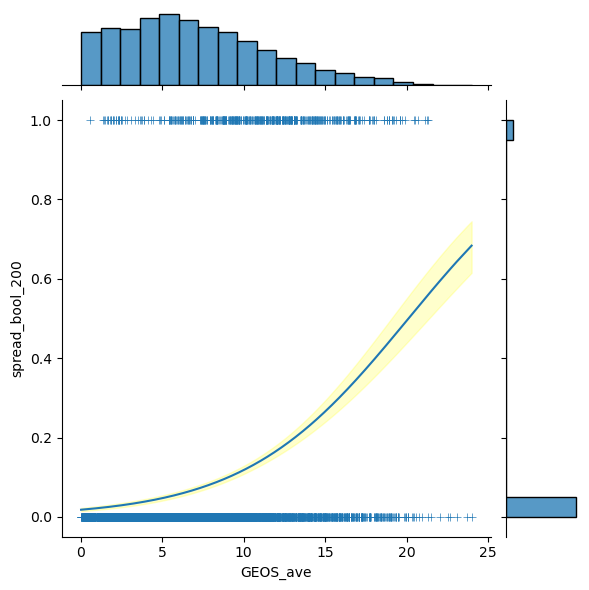

No growth detected, no values over nan in GEOS_ave
['most_common_null'] had the best accuracy (0.9134340547162108). Other scores were: 
          0                 1
0  0.000000              Null
1  0.910167        Model_mean
2  0.913434  most_common_null
Mean model's accuracy is between 0.9101674152715394 and 0.912209064924459


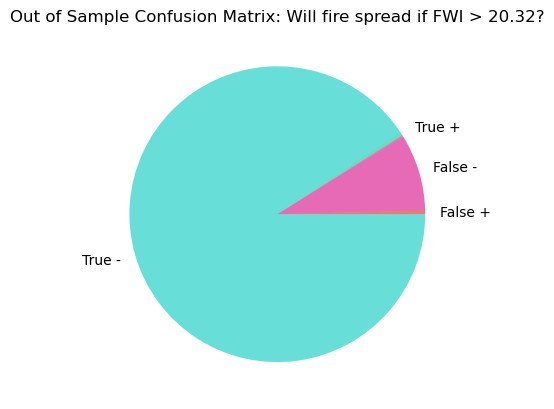

In [59]:


fire.loc[:, "spread_bool_200"] = fire.farea_diff > 2
fire.loc[:, "spread_bool_200"] = fire["spread_bool_200"].astype("float")

fire_test.loc[:, "spread_bool_200"] = fire_test.farea_diff > 2
fire_test.loc[:, "spread_bool_200"] = fire_test["spread_bool_200"].astype("float")


fire.loc[:, "spread_10km"] = fire.farea_diff_stand >= 10
fire.loc[:, "spread_10km"] = fire["spread_10km"].astype("int")

fire_test.loc[:, "spread_10km"] = fire_test.farea_diff_stand >= 10
fire_test.loc[:, "spread_10km"] = fire_test["spread_10km"].astype("int")




fire.loc[:, "n_newpixels_bool"] = fire.n_newpixels > 0
fire.loc[:,  "n_newpixels_bool"] = fire[ "n_newpixels_bool"].astype("int")

fire_test.loc[:, "n_newpixels_bool"] = fire_test.n_newpixels > 0
fire_test.loc[:, "n_newpixels_bool"] = fire_test[ "n_newpixels_bool"].astype("int")

fire.loc[:, "GEOS_ave"] = (fire['GEOS5_IMERGEARLY'] + fire['GEOS5_IMERGEARLY_shifted'])/ 2
fire_test.loc[:, "GEOS_ave"] = (fire_test['GEOS5_IMERGEARLY'] + fire_test['GEOS5_IMERGEARLY_shifted'])/ 2







model = make_logit(fire, fire_test, 'GEOS_ave', 'spread_bool_200') ## Doesn't seems super sensitive to frac_change
plt.close()

# x = 'GEOS5_IMERGEARLY'

# y = 'spread_bool'

# formula = f"{y} ~ {x}"

# pre_model = smf.logit(formula, data=fire)

# #testmake_logit(fire, fire_test, x = 'GEOS5_IMERGEARLY', y = 'spread_bool')

In [60]:
## Logit model for ignitions and for extinctions

import os

path = os.path.abspath("data/Quebec_v3_full_data_perimetersMAX_fwi_ful_timeseries_2025221.csv") ## Uses "max" FWI instead of average
fire_fl = pd.read_csv(path)
fire_fl['GEOS5_IMERGEARLY'] = fire_fl['GEOS-5.IMERGEARLY']

def just_the_igs(df,): ## Reminder that this will only acocunt for the earliest ignition from a multi-fire complex. 

    df_fr = df[~(df.geometry.isna())]
    t_min = df_fr.t.min()
    df["is_ig"] = False
    df.loc[(df.t == t_min), ['is_ig']] = True
    
    return(df)

def extinction(df, days_past = 1):
    df.loc[:, ['is_ext']] = False
    df.loc[:, ["t"]] = df.t.astype("datetime64[ns]")
    final_t = df[df.n_newpixels > 0].t.astype("datetime64[ns]").max()
    post_fire = final_t + timedelta(days = days_past)

    if (pd.isnull(np.datetime64(str(final_t)))):
        df.loc[(df.t == df.t.min()), ['is_ext']] = True
    else:
        df.loc[(df.t  > final_t)  & (df.t  <= post_fire), ['is_ext']] = True
    #print(final_t)
    #print(df.fireID.unique())
    #print(len(df[df["is_ext"] == True]))
    return(df)


fire_fl.fireID = fire_fl.fireID.astype("str")
post_fr_fl = fire_fl

post_fr_fl = post_fr_fl.groupby("fireID").apply(extinction).reset_index(drop = True)
post_fr_fl = post_fr_fl.groupby("fireID").apply(just_the_igs).reset_index(drop = True)

/tmp/ipykernel_1188/2873940340.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_1188/2873940340.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [61]:
def make_two_dfs(fire3):
    '''
    Makes two dataframes with roughly the same proportion of fires of different sizes
    '''
    max_area = fire3.groupby("fireID").farea.max()
    max_area = pd.DataFrame({"fireID": max_area.index, 
                            "farea_max" : max_area.values})
    
    
    max_area = max_area.sort_values(by = "farea_max")
    fit_ids = max_area.iloc[::2].fireID
    test_ids = max_area.iloc[1::2].fireID
    
    
    
    fire = fire3[fire3.fireID.isin(fit_ids)]
    fire_test = fire3[fire3.fireID.isin(test_ids)]
    return(fire, fire_test)

Optimization terminated successfully.
         Current function value: 0.023829
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.019637
         Iterations 10
Model has AIC of 1299.8, null model aic of 250.722


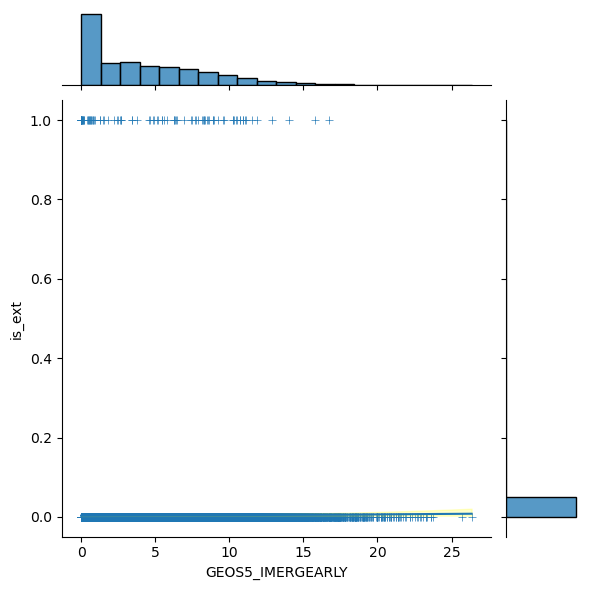

No growth detected, no values over nan in GEOS5_IMERGEARLY
No growth detected, no values over nan in GEOS5_IMERGEARLY
No growth detected, no values over nan in GEOS5_IMERGEARLY
No growth detected, no values over nan in GEOS5_IMERGEARLY
['most_common_null'] had the best accuracy (0.9963900233372228). Other scores were: 
         0                 1
0  0.00000              Null
1  0.00000        Model_mean
2  0.99639  most_common_null
Mean model's accuracy is between 0.0 and 0.0


/srv/conda/envs/notebook/lib/python3.12/site-packages/matplotlib/axes/_axes.py:3290: RuntimeWarning: invalid value encountered in divide


ValueError: cannot convert float NaN to integer

posx and posy should be finite values
posx and posy should be finite values


ValueError: need at least one array to concatenate

<Figure size 640x480 with 1 Axes>

In [62]:
post_fr_fl.is_ig = post_fr_fl.is_ig.astype("int")
post_fr_fl.is_ext = post_fr_fl.is_ext.astype("int")
post_fr_fl['GEOS5_IMERGEARLY_shifted'] = post_fr_fl.groupby("fireID")['GEOS-5.IMERGEARLY'].shift(1)

fr_in_sample, fr_out_sample = make_two_dfs(post_fr_fl)


model = make_logit(fire_delta = fr_in_sample, fire_test = fr_out_sample, x= 'GEOS5_IMERGEARLY', y = 'is_ext') ## Doesn't seems super sensitive to frac_change
#plt.close()




In [ ]:
#?